# Bayesian Active Learning

In [44]:
import os
os.chdir('/Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning')
print("Current working directory: {0}".format(os.getcwd()))

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload
%autoreload 2

Current working directory: /Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, make_circles, make_classification
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pickle

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, SubsetRandomSampler


from src.models.model import MLP, CNN
from src.data.data import get_dataloaders, TwoMoons
from src.models.train_model import train, test
from src.features.utils import random_query, query_the_oracle, plot_decision_bound, get_softmax_grid, get_entropy_grid

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# Set device
device = "mps" if torch.backends.mps.is_available() else "cpu"
device = 'cpu'
print(f"Using device: {device}")

FIGURE_PATH = '/Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning/reports/figures/'

Using device: cpu


### Define data, data loaders & training parameters

In [46]:
# generate data
moons_data = make_moons(n_samples = 1000, noise = 0.2, random_state=9)

# dataloader and dataset class
_, testloader = get_dataloaders(moons_data = moons_data, val_split = 0.2, batch_size=256, return_idx=True)
train_set = TwoMoons(moons_data = moons_data)

# model, optimizer nad hyper parameters'
drop_out = 0.1

model = MLP(drop_out=drop_out)
num_epochs = 100
batch_size = 256

# acrtive learning params
num_queries = 20
query_size = 1
lr = 6e-5

# posterior approx params
T = 30

# list of sampling strategies
strat_list = ['bald', 'entropy', 'margin', 'random']

init_pool_size = 3
init_pool_idx = np.random.randint(0,1000, size = init_pool_size).tolist()

#### Active learning with random sampling

ITER:  1
ITER:  2
ITER:  3
ITER:  4
ITER:  5


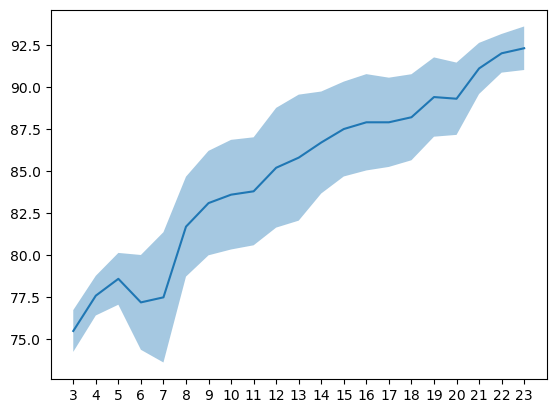

In [4]:
n_iter = 5
TEST_ACC = np.zeros((n_iter, num_queries+1))

print_acc = False
plot = True

for i in range(n_iter):
    print(f'ITER: {i+1:2d}')
    
    # reset dataset, model and optimizer
    train_set.reset_mask()
    model = MLP(drop_out=drop_out)
    optimizer = optim.Adam(model.parameters(), lr = lr)
    
    # train on initial pool
    train_set.update_mask(init_pool_idx)
    labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                    sampler=SubsetRandomSampler(init_pool_idx), shuffle = False)

    model = train(model, labeled_loader, optimizer, device, num_epochs=300, plot = False, printout = False)
    TEST_ACC[i,0] = test(model, testloader, device, display = False)

    for query in range(num_queries):
        # quering data points
        sample_idx = query_the_oracle(model, train_set, device, query_strategy='random', query_size=query_size, T = T, batch_size=batch_size)
        train_set.update_mask(sample_idx)
        labeled_idx = np.where(train_set.unlabeled_mask == 0)[0]
        labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                    sampler=SubsetRandomSampler(labeled_idx), shuffle=False)

        # train model
        model = train(model,labeled_loader,optimizer, device, num_epochs=num_epochs, plot = False, printout = False)

        # test model
        test_acc = test(model, testloader, device, display = False)
        TEST_ACC[i,query+1] = test_acc
        
        std = TEST_ACC.std(0)/np.sqrt(n_iter)
        mean  = TEST_ACC.mean(0)

        if print_acc:
            print(f'# Samples: {init_pool_size + query*query_size:3d} | Test accururacy : {test_acc:.2f}%')

if plot:
    x = np.arange(init_pool_size, num_queries+init_pool_size+1, dtype=int)
    plt.plot(x, mean)
    plt.fill_between(x, mean+std, mean-std, alpha = 0.4)
    plt.xticks(x)
    plt.show()

### Active Learning w. different acquisition strategies

STRATEGY: bald
ITER:  1
# Samples:   3 | Test accururacy : 75.00%
# Samples:   4 | Test accururacy : 78.00%
# Samples:   5 | Test accururacy : 84.00%
# Samples:   6 | Test accururacy : 85.00%
# Samples:   7 | Test accururacy : 85.50%
# Samples:   8 | Test accururacy : 86.50%
# Samples:   9 | Test accururacy : 89.00%
# Samples:  10 | Test accururacy : 89.50%
# Samples:  11 | Test accururacy : 89.50%
# Samples:  12 | Test accururacy : 90.00%
# Samples:  13 | Test accururacy : 90.00%
# Samples:  14 | Test accururacy : 90.50%
# Samples:  15 | Test accururacy : 92.00%
# Samples:  16 | Test accururacy : 92.00%
# Samples:  17 | Test accururacy : 92.00%
# Samples:  18 | Test accururacy : 92.00%
# Samples:  19 | Test accururacy : 92.00%
# Samples:  20 | Test accururacy : 92.00%
# Samples:  21 | Test accururacy : 92.00%
# Samples:  22 | Test accururacy : 92.00%
ITER:  2
# Samples:   3 | Test accururacy : 86.50%
# Samples:   4 | Test accururacy : 89.00%
# Samples:   5 | Test accururacy : 90.00%
#

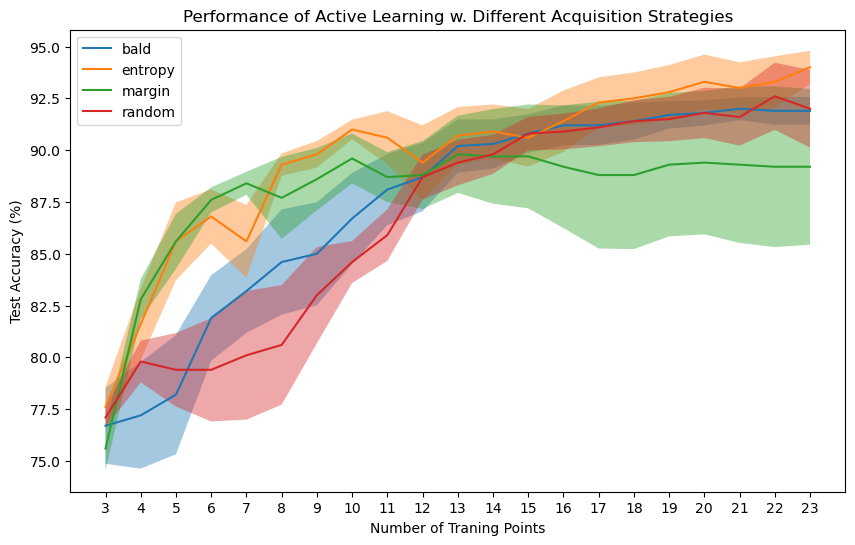

In [49]:
query_dict = {
    'bald': {'acc_mean': [], 'acc_se': []},
    'random': {'acc_mean': [], 'acc_se': []},
    'entropy': {'acc_mean': [], 'acc_se': []},
    'margin': {'acc_mean': [], 'acc_se': []}
}

## setup ##
save_dict = False
plot = True

n_iter = 5
TEST_ACC = np.zeros((n_iter, num_queries+1))


# seed list
for r, s in enumerate(strat_list):
    #torch.manual_seed(r)
    
    print(f'STRATEGY: {s}')
    for i in range(n_iter):
        print(f'ITER: {i+1:2d}')
        
        # reset dataset, model and optimizer
        train_set.reset_mask()
        model = MLP(drop_out=drop_out)
        optimizer = optim.Adam(model.parameters(), lr = lr)
        
        # train on initial pool
        train_set.update_mask(init_pool_idx)
        labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                        sampler=SubsetRandomSampler(init_pool_idx), shuffle = False)
    
        model = train(model, labeled_loader, optimizer, device, num_epochs=300, plot = False, printout = False)
        TEST_ACC[i,0] = test(model, testloader, device, display = False)
    
        for query in range(num_queries):
            # quering data points
            sample_idx = query_the_oracle(model, train_set, device, query_strategy=s, query_size=query_size, T = T, batch_size=batch_size)
            train_set.update_mask(sample_idx)
            labeled_idx = np.where(train_set.unlabeled_mask == 0)[0]
            labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                        sampler=SubsetRandomSampler(labeled_idx), shuffle=False)

            # train model
            model = train(model,labeled_loader,optimizer, device, num_epochs=num_epochs, plot = False, printout = False)

            # test model
            test_acc = test(model, testloader, device, display = False)
            TEST_ACC[i,query+1] = test_acc

            print(f'# Samples: {init_pool_size + query*query_size:3d} | Test accururacy : {test_acc:.2f}%')

    query_dict[s]['acc_se'] = TEST_ACC.std(0)/np.sqrt(n_iter)
    query_dict[s]['acc_mean']  = TEST_ACC.mean(0)
    
if save_dict:
    with open("QUERY_DICT_50", "wb") as fp:
        pickle.dump(query_dict, fp)

if plot:
    x = np.arange(init_pool_size,num_queries+init_pool_size+1,dtype=int)
    plt.figure(figsize=(10,6))

    for s in strat_list:
        mean = query_dict[s]['acc_mean']
        std = query_dict[s]['acc_se']
        plt.plot(x, mean, label = s)
        plt.legend()
        plt.title('Performance of Active Learning w. Different Acquisition Strategies')
        plt.xlabel('Number of Traning Points')
        plt.ylabel('Test Accuracy (%)')
        plt.xticks(x, x)
        plt.fill_between(x, mean+std, mean-std, alpha = 0.4)
    plt.savefig('reports/figures/TwoMoons_results_11.png')
    plt.show()

### Plot decision boundary for the different acquisition strategies

calculating: bald
calculating: entropy
calculating: margin
calculating: random


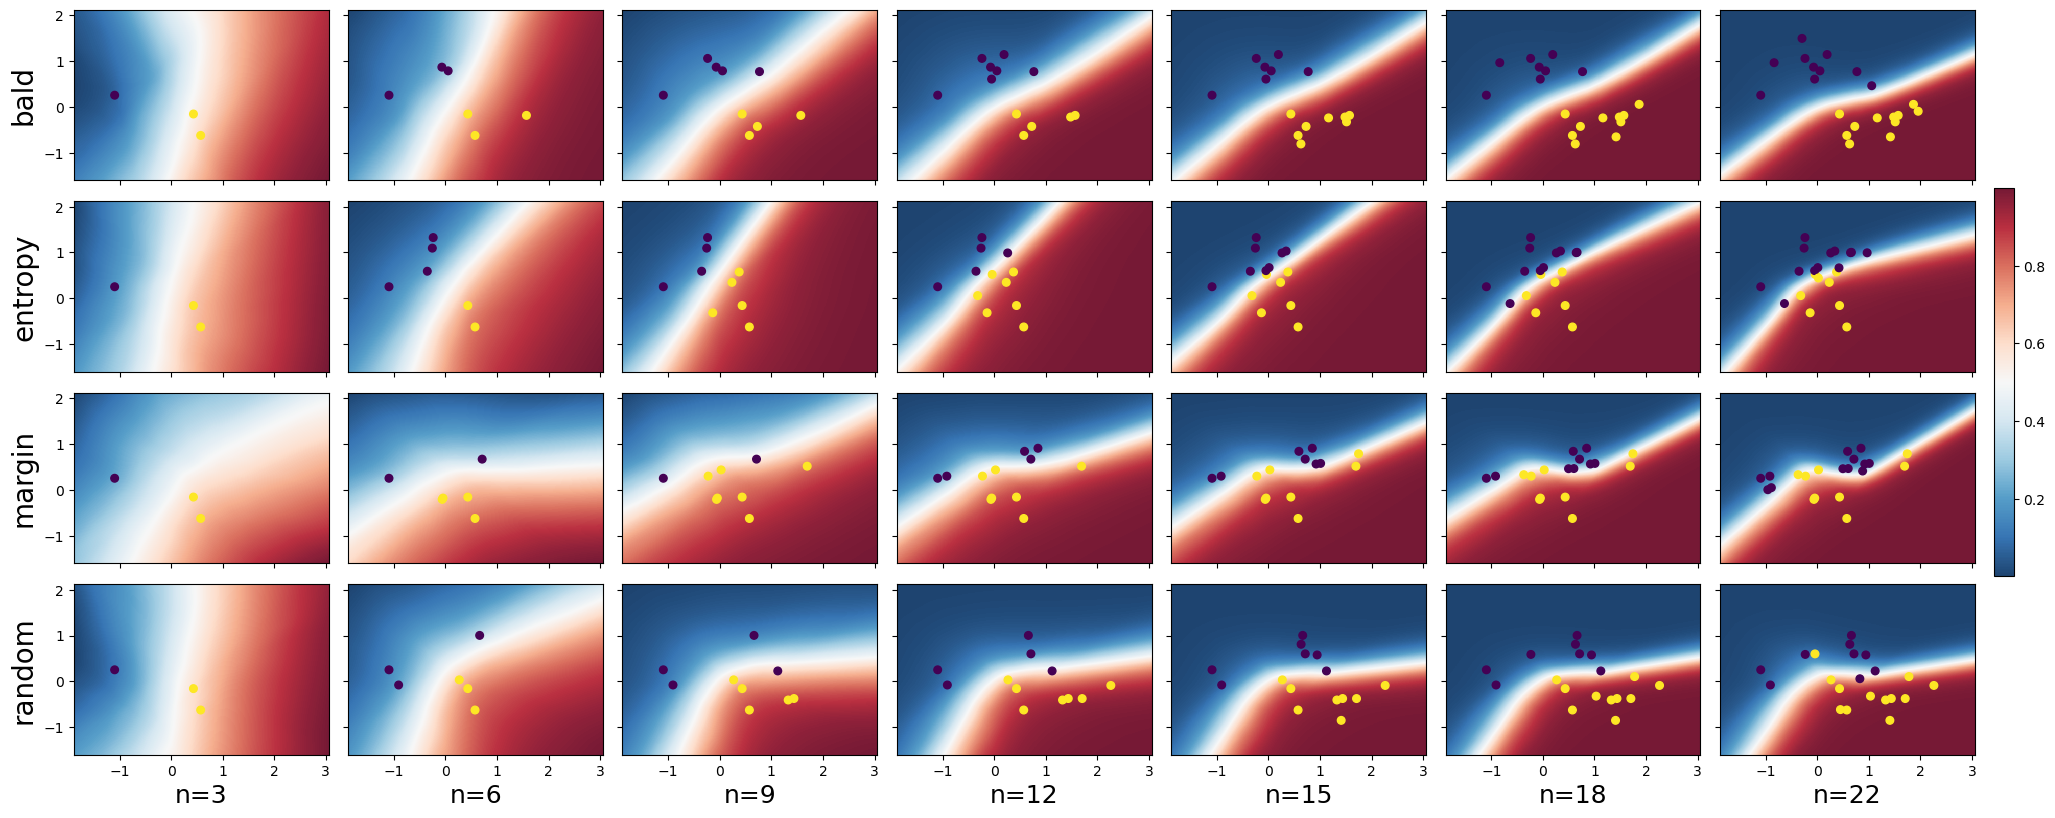

In [14]:
num_queries = 6
query_size = 3

# figure init
fig, axs = plt.subplots(nrows=len(strat_list), ncols=num_queries+1, figsize=(20, 8),sharex=True, sharey=True)


for i, strat in enumerate(strat_list):
    print(f'calculating: {strat}')
    j = 0
    
    # reset dataset, model and optimizer
    train_set.reset_mask()
    model = MLP(drop_out=drop_out)
    optimizer = optim.Adam(model.parameters(), lr = lr)
    
    # train on initial pool
    train_set.update_mask(init_pool_idx)
    labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                        sampler=SubsetRandomSampler(init_pool_idx), shuffle = False)
    
    model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)
    
    # plot initial 10 data points, first col in plot
    X, y, xx, yy, softmax_out = get_softmax_grid(model, moons_data = moons_data)

    mesh = axs[i,j].pcolormesh(xx, yy, softmax_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
    axs[i,0].scatter(X[init_pool_idx,0], X[init_pool_idx,1], c = y[init_pool_idx], s = 30)
    axs[i,0].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
    axs[i,0].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)
    
    labeled_idx_list = []
    
    for query in range(num_queries):
        # quering data points
        sample_idx = query_the_oracle(model, train_set, device, query_strategy=strat, query_size=query_size, batch_size=batch_size, T = T)
        train_set.update_mask(sample_idx)
        labeled_idx = np.where(train_set.unlabeled_mask == 0)[0]
        labeled_idx_list.extend(sample_idx)
                
        # define a list for plotting the initial 10 points + the queried points
        plot_idx = init_pool_idx + labeled_idx_list      
                
        labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                        sampler=SubsetRandomSampler(labeled_idx), shuffle = False)

        # train model
        model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)
        
        # plot grid and scatter for the rest of the cols.
        X, y, xx, yy, softmax_out = get_softmax_grid(model, moons_data = moons_data)

        mesh = axs[i,j+1].pcolormesh(xx, yy, softmax_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
        axs[i,j+1].scatter(X[plot_idx,0], X[plot_idx,1], c = y[plot_idx], s = 30)
        axs[i,j+1].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
        axs[i,j+1].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)
        
        j = j +1

fig.tight_layout()
fig.colorbar(mesh, ax=axs.ravel().tolist(), fraction=0.01, pad=0.01)

# set ylabels to strategy
for i, strat in enumerate(strat_list):
    axs[i,0].set_ylabel(strat, fontsize=20)
    #axs[i,0].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)

# set xlabels to number of sampled data points.
ns = np.linspace(0, query_size*num_queries+1, num_queries+1)

for i, n in enumerate(ns):
    axs[len(strat_list)-1,i].set_xlabel(f'n={int(init_pool_size+n)}', fontsize=18)
    #axs[len(strat_list)-1,i].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)

plt.savefig(FIGURE_PATH+'dec_bound_8.png')
plt.show()

### Plotting acquisition function output

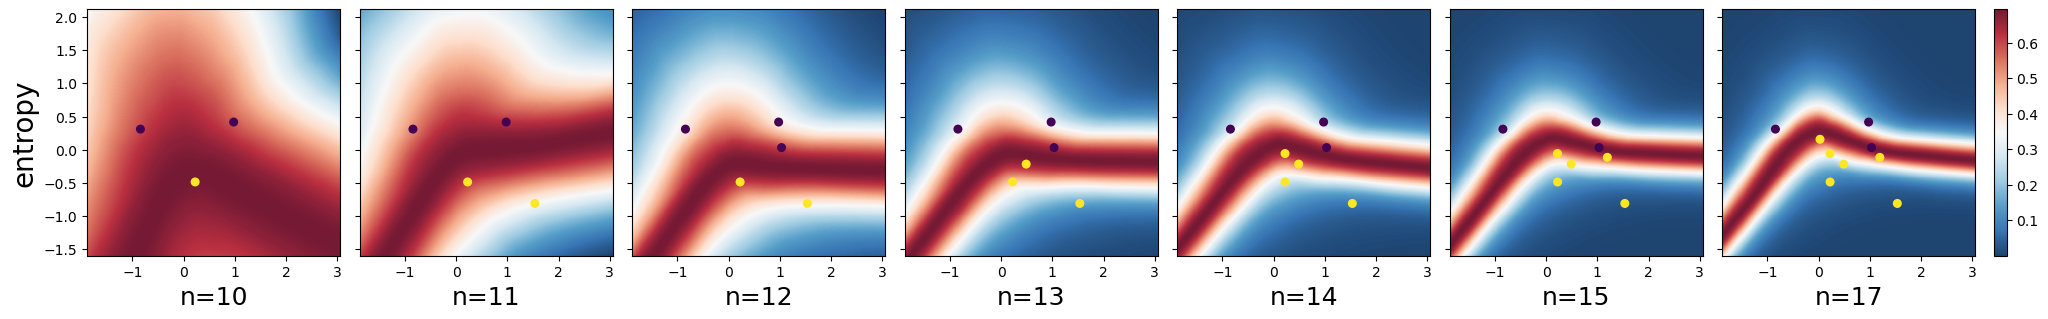

In [26]:
lr = 1e-4
num_queries = 6
query_size = 1

# figure init
fig, axs = plt.subplots(nrows=1, ncols=num_queries+1, figsize=(20, 3),sharex=True, sharey=True)
j = 0

# reset dataset, model and optimizer
train_set.reset_mask()
model = MLP(drop_out=drop_out)
optimizer = optim.Adam(model.parameters(), lr = lr)

# train on initial pool
train_set.update_mask(init_pool_idx)
labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                    sampler=SubsetRandomSampler(init_pool_idx), shuffle = False)

model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)

# plot initial 10 data points, first col in plot
X, y, xx, yy, entropy_out = get_entropy_grid(model, moons_data = moons_data)

mesh = axs[0].pcolormesh(xx, yy, entropy_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
axs[0].scatter(X[init_pool_idx,0], X[init_pool_idx,1], c = y[init_pool_idx], s = 30)
axs[0].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
axs[0].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)

labeled_idx_list = []

for i, query in enumerate(range(num_queries)):
    # quering data points
    
    sample_idx = query_the_oracle(model, train_set, device, query_strategy='entropy', query_size=query_size)
    train_set.update_mask(sample_idx)
    labeled_idx = np.where(train_set.unlabeled_mask == 0)[0]
    labeled_idx_list.extend(sample_idx)
    
    # define a list for plotting the initial 10 points + the queried points
    plot_idx = init_pool_idx + labeled_idx_list      
            
    labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                    sampler=SubsetRandomSampler(labeled_idx), shuffle = False)

    # train model
    model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)
    
    # plot grid and scatter for the rest of the cols.
    X, y, xx, yy, entropy_out = get_entropy_grid(model, moons_data = moons_data)

    mesh = axs[i+1].pcolormesh(xx, yy, entropy_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
    axs[i+1].scatter(X[plot_idx,0], X[plot_idx,1], c = y[plot_idx], s = 30)
    axs[i+1].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
    axs[i+1].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)


fig.tight_layout()
fig.colorbar(mesh, ax=axs.ravel().tolist(), fraction=0.01, pad=0.01)

# set ylabels to strategy
axs[0].set_ylabel('entropy', fontsize=20)

# set xlabels to number of sampled data points.
ns = np.linspace(0, query_size*num_queries+1, num_queries+1)

for i, n in enumerate(ns):
    axs[i].set_xlabel(f'n={int(10+n)}', fontsize=18)

plt.savefig(FIGURE_PATH+'dec_bound_10.png')
plt.show()

### BALD with Monte Carlo Dropout

Experiments:
- Different values of T for MC_dropout.
- Laplace Approx
- Plot BALD output

Questions:
- Dropout in which layers?
- Does the output of BALD look correct?


- plot variance in 2D.

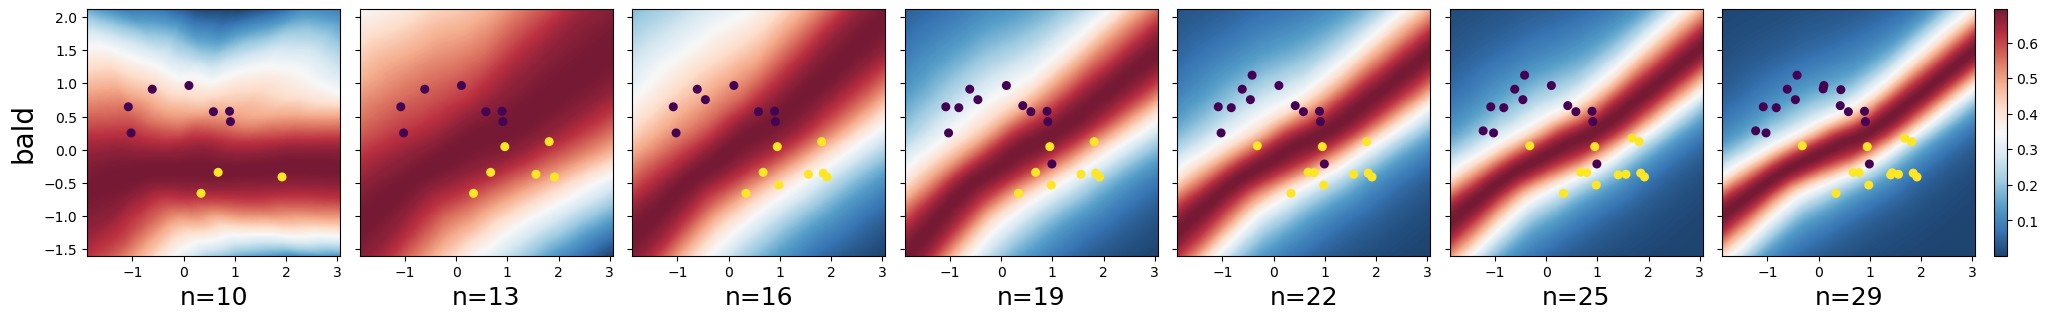

In [9]:
lr = 1e-4
num_queries = 6
query_size = 3

# figure init
fig, axs = plt.subplots(nrows=1, ncols=num_queries+1, figsize=(20, 3),sharex=True, sharey=True)
j = 0

# reset dataset, model and optimizer
train_set.reset_mask()
model = MLP(drop_out=drop_out)
optimizer = optim.Adam(model.parameters(), lr = lr)

# train on initial pool
train_set.update_mask(init_pool_idx)
labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                    sampler=SubsetRandomSampler(init_pool_idx), shuffle = False)

model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)

# plot initial 10 data points, first col in plot
X, y, xx, yy, entropy_out = get_entropy_grid(model, moons_data = moons_data)

mesh = axs[0].pcolormesh(xx, yy, entropy_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
axs[0].scatter(X[init_pool_idx,0], X[init_pool_idx,1], c = y[init_pool_idx], s = 30)
axs[0].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
axs[0].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)

labeled_idx_list = []

for i, query in enumerate(range(num_queries)):
    # quering data points
    
    sample_idx = query_the_oracle(model, train_set, device, query_strategy='bald', query_size=query_size, T = 100)
    train_set.update_mask(sample_idx)
    labeled_idx = np.where(train_set.unlabeled_mask == 0)[0]
    labeled_idx_list.extend(sample_idx)
    
    # define a list for plotting the initial 10 points + the queried points
    plot_idx = init_pool_idx + labeled_idx_list      
            
    labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                    sampler=SubsetRandomSampler(labeled_idx), shuffle = False)

    # train model
    model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)
    
    # plot grid and scatter for the rest of the cols.
    X, y, xx, yy, entropy_out = get_entropy_grid(model, moons_data = moons_data)

    mesh = axs[i+1].pcolormesh(xx, yy, entropy_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
    axs[i+1].scatter(X[plot_idx,0], X[plot_idx,1], c = y[plot_idx], s = 30)
    axs[i+1].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
    axs[i+1].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)


fig.tight_layout()
fig.colorbar(mesh, ax=axs.ravel().tolist(), fraction=0.01, pad=0.01)

# set ylabels to strategy
axs[0].set_ylabel('bald', fontsize=20)

# set xlabels to number of sampled data points.
ns = np.linspace(0, query_size*num_queries+1, num_queries+1)

for i, n in enumerate(ns):
    axs[i].set_xlabel(f'n={int(10+n)}', fontsize=18)

plt.savefig(FIGURE_PATH+'dec_bound_10.png')
plt.show()

todo:
- Check ordering of BALD
- check indexing (list of 6000?)

In [40]:

def BALD_query(model, device, data_loader, batch_size, query_size = 10, T = 30, method = 'MC_drop'):

    # get appox
    model.train()
    
    indices = []
    if method == 'MC_drop':
        logits = torch.zeros((len(data_loader)*batch_size,2,T))
        for t in range(T):
            for i, batch in enumerate(data_loader):
                X, y, idx = batch
                logit = model(X.to(device))
                logits[i*len(y):i*len(y)+len(y),:,t] = logit
                
                if t == 0:
                    indices.extend(idx.tolist())

        p_hat = F.softmax(logits, dim = 1)
        p_hat_mean_T = p_hat.mean(2)
        
        first_term = (-p_hat_mean_T*torch.log(p_hat_mean_T)).sum(1)
        second_term = (-p_hat*torch.log(p_hat)).sum(1).mean(1)
        
        BALD_scores = first_term-second_term
            
    if method == 'Laplace':
        print('Not implemented yet!')
        
    scores = np.asarray(BALD_scores.cpu().tolist())
    ind = np.asarray(indices)
    sorted_pool = np.argsort(scores)
    
    t = ind[sorted_pool][0:query_size]
    return scores, sorted_pool, ind, ind[sorted_pool][0:query_size]

In [41]:
scores, sorted_pool, ind, _ =BALD_query(model, device, test_loader, batch_size=100)

torch.Size([200])


In [42]:
sorted_pool

array([101, 104,  95,  71,  11,  35, 165,   9,  75,  99, 172, 199,   0,
       121, 183,  70,  20,  26, 157, 118,  84, 188, 140,  47, 166,  14,
       108, 111,  44, 182, 139,  97, 106, 100, 103, 194, 158,  90, 186,
        80,  25, 138, 151, 193,  60, 130, 125,  50,  61,  63,  53,  73,
       113,  62, 177,  79,  28,  34,   7,  85, 185,  87, 149,  29,  19,
        93, 167, 147,  64, 119, 159, 197, 189,  38,  49,  89, 171,  94,
        51, 190,  17, 176, 160,  81,  40, 128,  22,  30,  92,  77,  68,
       170, 122,  91,  86, 181,  78,  23, 126,  24, 143, 148, 115, 162,
       150,   8, 154,   3,  37,  54,   4,  33,  46,  42, 145,  12, 116,
       141,   1, 156,  88, 196,  83,  48,  18, 144, 129, 112, 168, 155,
        45, 142, 169,  32,   5,  52,  27, 117, 184, 152, 134,  72,  13,
        98, 163, 109, 174, 110,  66,  76, 124, 191, 179, 146, 127, 131,
       123,   2, 105,  31, 161, 133, 153,  41, 137,  43, 102, 107,  16,
        69, 180, 178,  59,  55,  65,  21,  82,  57, 187,   6, 17

In [43]:
ind.shape

(200,)

In [25]:
print(scores.min())
scores

0.00044730864465236664


array([0.00105048, 0.00255281, 0.00350672, 0.00331524, 0.00428557,
       0.00637007, 0.02270722, 0.00153113, 0.00396064, 0.00224997,
       0.05622536, 0.00059338, 0.00209832, 0.00433025, 0.00112379,
       0.03718245, 0.00680533, 0.00675575, 0.00277205, 0.00234475,
       0.00059192, 0.02102131, 0.004721  , 0.00108014, 0.0045924 ,
       0.00085391, 0.0012799 , 0.00589257, 0.00200409, 0.00419867,
       0.00127384, 0.0043627 , 0.01476663, 0.00388122, 0.0039992 ,
       0.00088671, 0.05095464, 0.00136682, 0.0042035 , 0.0448547 ,
       0.00291799, 0.01896626, 0.00263227, 0.00630701, 0.00110242,
       0.0013105 , 0.00257134, 0.00138871, 0.00346297, 0.00111113,
       0.00317556, 0.00121949, 0.00187402, 0.00153099, 0.00242645,
       0.00764355, 0.00597875, 0.01275158, 0.02900594, 0.01499915,
       0.00213845, 0.00157022, 0.00262776, 0.00106689, 0.00196673,
       0.00851369, 0.00567991, 0.02333894, 0.00139718, 0.01033877,
       0.0037459 , 0.00111   , 0.00670412, 0.00216603, 0.00791

Epoch:   0 | Train Loss: 0.69 | Train Acc: 55.6%
Epoch:   1 | Train Loss: 0.67 | Train Acc: 65.5%
Epoch:   2 | Train Loss: 0.66 | Train Acc: 72.5%
Epoch:   3 | Train Loss: 0.65 | Train Acc: 74.9%
Epoch:   4 | Train Loss: 0.63 | Train Acc: 77.6%
Epoch:   5 | Train Loss: 0.61 | Train Acc: 80.8%
Epoch:   6 | Train Loss: 0.59 | Train Acc: 80.2%
Epoch:   7 | Train Loss: 0.58 | Train Acc: 80.1%
Epoch:   8 | Train Loss: 0.56 | Train Acc: 80.9%
Epoch:   9 | Train Loss: 0.55 | Train Acc: 81.1%
Epoch:  10 | Train Loss: 0.53 | Train Acc: 81.2%
Epoch:  11 | Train Loss: 0.52 | Train Acc: 80.8%
Epoch:  12 | Train Loss: 0.51 | Train Acc: 81.8%
Epoch:  13 | Train Loss: 0.50 | Train Acc: 81.2%
Epoch:  14 | Train Loss: 0.48 | Train Acc: 82.2%
Epoch:  15 | Train Loss: 0.47 | Train Acc: 83.1%
Epoch:  16 | Train Loss: 0.46 | Train Acc: 81.9%
Epoch:  17 | Train Loss: 0.45 | Train Acc: 82.6%
Epoch:  18 | Train Loss: 0.43 | Train Acc: 83.0%
Epoch:  19 | Train Loss: 0.42 | Train Acc: 82.4%
Epoch:  20 | Train L

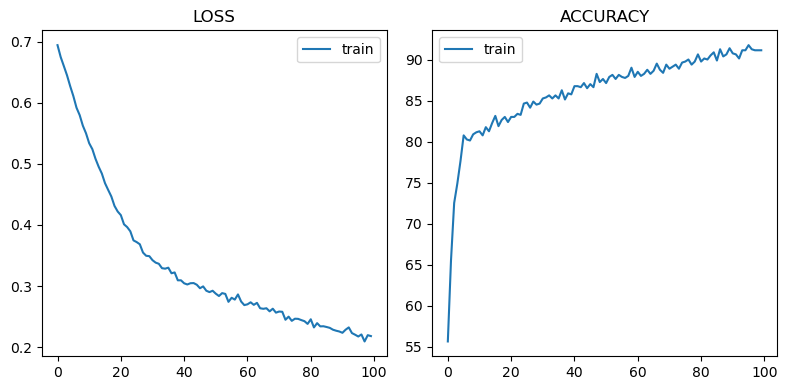

Accuracy on the test set: 94.5 %


In [9]:
batch_size = 100
train_loader, test_loader = get_dataloaders(moons_data = moons_data, val_split = 0.2, batch_size=batch_size, return_idx=True)

lr = 1e-4
model = MLP(drop_out=0.2)
optimizer = optim.Adam(model.parameters(), lr = lr)

train(model, train_loader, optimizer, device, num_epochs=100, plot = True)

acc = test(model, test_loader, device, display = True)

_, first_term, second_term = BALD_query(model, device, test_loader, batch_size=batch_size, query_size=100, T=30)
    

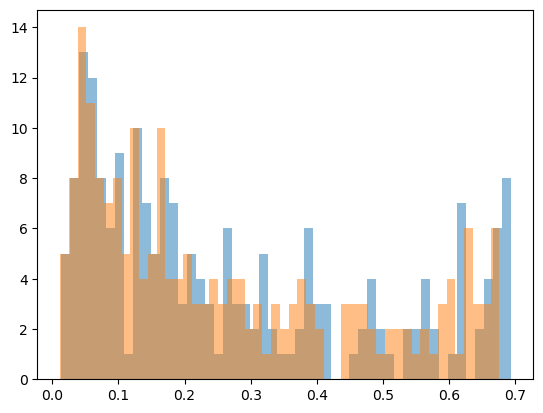

In [36]:
plt.hist(first_term, alpha = 0.5, bins = 50)
plt.hist(second_term, alpha = 0.5, bins = 50)
plt.show()

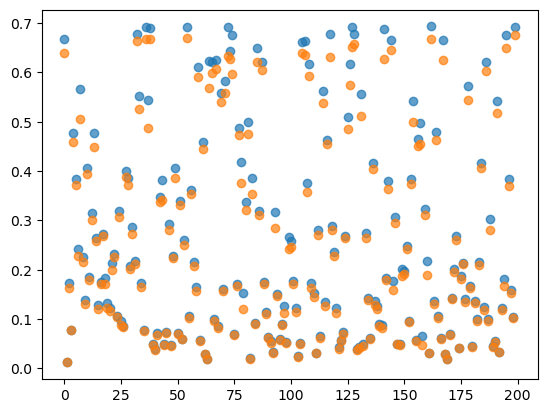

In [37]:
x = np.arange(0,len(first_term), dtype=int)

plt.scatter(x, first_term, alpha = 0.7)
plt.scatter(x, second_term, alpha= 0.7)
plt.grid(color='gray', which = 'minor')
plt.show()

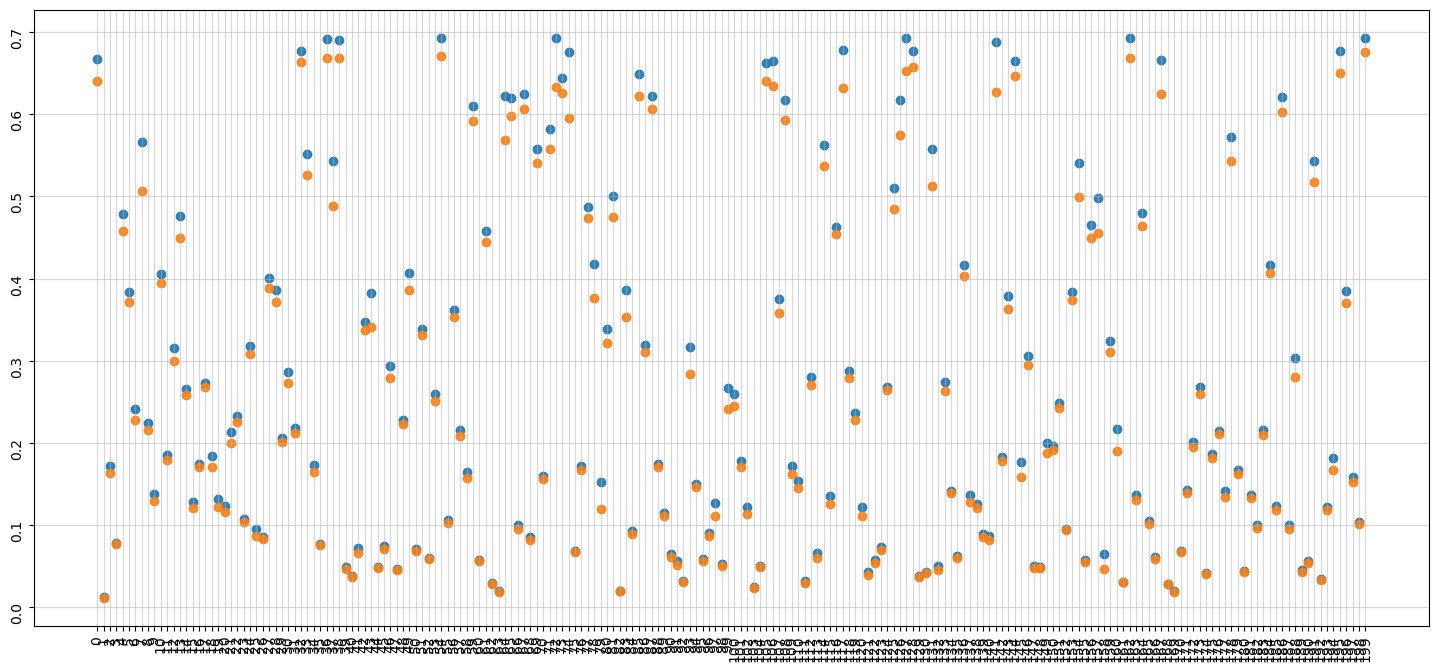

In [38]:
fig = plt.figure(figsize = (18,8))
ax = fig.add_subplot(1, 1, 1)

ax.set_xticks(x)
ax.tick_params(labelrotation=90)

# And a corresponding grid
ax.grid(which='major')

# Or if you want different settings for the grids:
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

ax.scatter(x, first_term, alpha = 0.9)
ax.scatter(x, second_term, alpha= 0.9)

plt.show()

### Laplace Approximation

In [19]:
from laplace import Laplace

train_loader, test_loader = get_dataloaders(moons_data = moons_data, val_split = 0.2, batch_size=256, return_idx=False)


# Pre-trained model
model = MLP(drop_out=0.50)  

# User-specified LA flavor
la = Laplace(model, 'classification',
             subset_of_weights='all',
             hessian_structure='full')
la.fit(train_loader)

/Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning/env/lib/python3.8/site-packages/backpack/extensions/backprop_extension.py:106: UserWarning: Extension saving to grad_batch does not have an extension for Module <class 'src.models.model.MLP'> although the module has parameters
  warnings.warn(


In [20]:
la.optimize_prior_precision(method='CV', val_loader=test_loader)

In [21]:
la_samples = la.sample(n_samples = 1000)

In [22]:
la_samples.shape

torch.Size([1000, 10602])

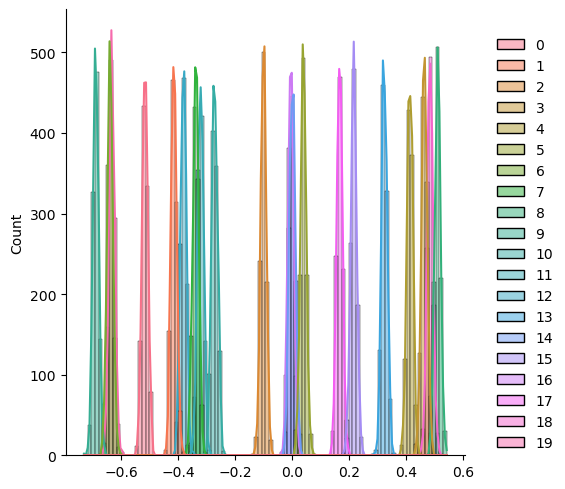

In [23]:
post_weights = la.sample(1000).detach().cpu().numpy()
sns.displot(post_weights[:,:20], bins = 100, kde = True)
plt.show()